# Particle Mass Regression using Deep Learning

This project aims to predict the mass of particles from jet images using deep learning models. Two approaches were explored:
1. Convolutional Neural Network (CNN)
2. Fully Connected Neural Network (Baseline)

The models are compared to understand the impact of model complexity and dataset size.


---

# Importing Libraries

In [2]:
import torch 
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pyarrow.parquet as pq
import random

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) 

    np.random.seed(seed)
    random.seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Data Loading & Preprocessing
The input data was normalized to improve training stability. The target variable was also standardized.

In [4]:
pq_file = pq.ParquetFile("D:/top_gun_opendata_0.parquet")

batch = next(pq_file.iter_batches(batch_size=3000))
df = batch.to_pandas()
print(df.shape)

(3000, 5)


In [5]:
def process_sample(sample):
    sample = sample[:4]

    processed = []

    for comp in sample:
        comp = list(comp)                
        comp = np.array(comp, dtype=np.float32)

        processed.append(comp)

    sample = np.stack(processed)   

    return sample

In [6]:
X = np.array([process_sample(s) for s in df['X_jet']])
y = df["m"].values

print("Shape:", X.shape)

Shape: (3000, 4, 125, 125)


In [7]:
print(X[0].shape)

(4, 125, 125)


In [8]:
X = (X - X.mean()) / X.std()

y_mean = y.mean()
y_std = y.std()

y = (y - y_mean) / (y_std + 1e-8)

print("X shape:", X.shape)  
print("y shape:", y.shape)

assert X.shape[1:] == (4, 125, 125), "Shape issue!"
print("Preprocessing done ")

X shape: (3000, 4, 125, 125)
y shape: (3000,)
Preprocessing done 


# Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (2100, 4, 125, 125)
Test: (900, 4, 125, 125)


## Converting to pytorch tensors

In [10]:
X_train = torch.tensor(X_train)
y_train = torch.tensor(y_train)

X_test = torch.tensor(X_test)
y_test = torch.tensor(y_test)

## Data Set and Data loader 

In [11]:
class JetDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [12]:
train_dataset = JetDataset(X_train, y_train)
test_dataset = JetDataset(X_test, y_test)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    generator=g
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,   
    generator=g      
)

### Training, Validating & Saving Model Function

In [13]:
def train_model(model, train_loader, test_loader, save_path, epochs=25):
    import torch
    import torch.nn as nn

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []

    best_val_loss = float('inf')   

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device).float()
            y_batch = y_batch.to(device).float()

            optimizer.zero_grad()
            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # Validation 
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device).float()
                y_batch = y_batch.to(device).float()

                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                val_loss += loss.item()

        val_loss /= len(test_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)

    print(f"Training complete. Best model saved at {save_path}")

    return model, train_losses, val_losses

## Prediction Function

In [14]:
def get_predictions(model, loader):
    model.eval()
    preds, true = [], []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device).float()

            outputs = model(X_batch)

            preds.extend(outputs.cpu().numpy())
            true.extend(y_batch.numpy())

    return np.array(preds), np.array(true)


---

# CNN Model

A Convolutional Neural Network was used to capture spatial features from jet images.

In [15]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(4, 16, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(32, 1)   
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x.squeeze()

## Training, Validating & Saving  Best Model

In [16]:
cnn_model = CNNModel()

cnn_model, train_losses_cnn, val_losses_cnn = train_model(
    cnn_model, train_loader, test_loader, save_path="best_model_cnn.pth"
)

Epoch 1: Train Loss = 0.9977, Val Loss = 1.0463
Epoch 2: Train Loss = 0.9934, Val Loss = 1.0414
Epoch 3: Train Loss = 0.9895, Val Loss = 1.0401
Epoch 4: Train Loss = 0.9913, Val Loss = 1.0389
Epoch 5: Train Loss = 0.9908, Val Loss = 1.0389
Epoch 6: Train Loss = 0.9897, Val Loss = 1.0386
Epoch 7: Train Loss = 0.9881, Val Loss = 1.0380
Epoch 8: Train Loss = 0.9919, Val Loss = 1.0378
Epoch 9: Train Loss = 0.9885, Val Loss = 1.0377
Epoch 10: Train Loss = 0.9888, Val Loss = 1.0375
Epoch 11: Train Loss = 0.9876, Val Loss = 1.0378
Epoch 12: Train Loss = 0.9890, Val Loss = 1.0378
Epoch 13: Train Loss = 0.9873, Val Loss = 1.0373
Epoch 14: Train Loss = 0.9885, Val Loss = 1.0375
Epoch 15: Train Loss = 0.9869, Val Loss = 1.0375
Epoch 16: Train Loss = 0.9878, Val Loss = 1.0374
Epoch 17: Train Loss = 0.9887, Val Loss = 1.0372
Epoch 18: Train Loss = 0.9869, Val Loss = 1.0373
Epoch 19: Train Loss = 0.9882, Val Loss = 1.0370
Epoch 20: Train Loss = 0.9852, Val Loss = 1.0369
Epoch 21: Train Loss = 0.9873

In [20]:
cnn_model.load_state_dict(torch.load("best_model_cnn.pth"))
cnn_model.eval()

CNNModel(
  (conv_layers): Sequential(
    (0): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [21]:
preds_cnn, true_cnn = get_predictions(cnn_model, test_loader)
preds_cnn = preds_cnn * y_std + y_mean
true_cnn = true_cnn * y_std + y_mean

In [22]:
rmse_cnn = np.sqrt(mean_squared_error(true_cnn, preds_cnn))
mae_cnn = mean_absolute_error(true_cnn, preds_cnn)
r2_cnn = r2_score(true_cnn, preds_cnn)

print("CNN RMSE:", rmse_cnn)
print("CNN MAE:", mae_cnn)
print("CNN R2 SCORE:", r2_cnn)

CNN RMSE: 119.82225752326717
CNN MAE: 103.8985146402221
CNN R2 SCORE: -0.0007830047469024048


# Loss Curve

In [49]:
%cd C:\Users\LENOVO\GSOC_test\anaconda_projects

C:\Users\LENOVO\GSOC_test\anaconda_projects


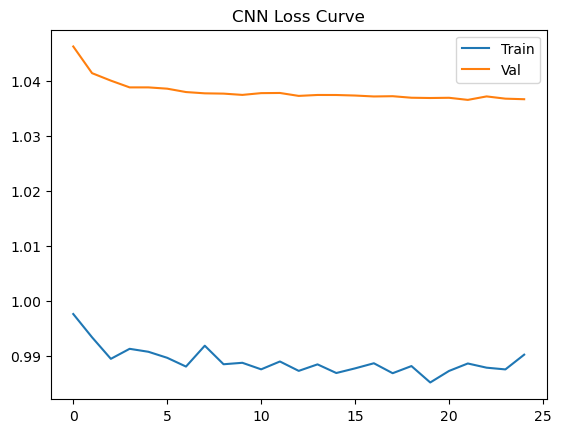

In [50]:
plt.plot(train_losses_cnn, label="Train")
plt.plot(val_losses_cnn, label="Val")
plt.legend()
plt.title("CNN Loss Curve")
plt.savefig("results/loss_plot_cnn.png")
plt.show()

# Prediction Curve

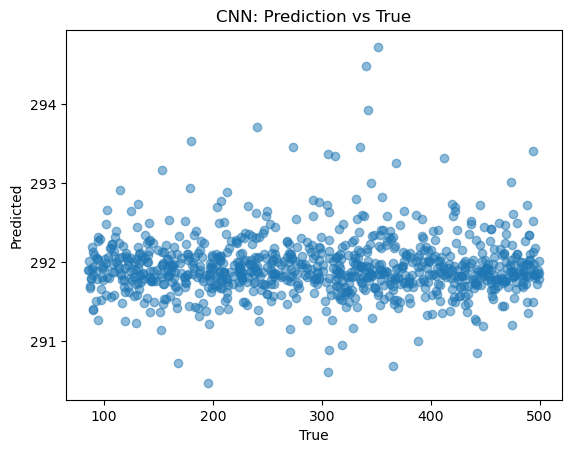

In [51]:
plt.scatter(true_cnn, preds_cnn, alpha=0.5)
plt.title("CNN: Prediction vs True")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.savefig("results/prediction_plot_cnn.png")
plt.show()

--- 
# Fully Connected Model

A fully connected model was used as a baseline to evaluate learning capability.

In [25]:
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(4*125*125, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x).squeeze()

In [26]:
fc_model = SimpleModel()
fc_model, train_losses_fc, val_losses_fc = train_model(
    fc_model, train_loader, test_loader, save_path="best_model_fc.pth"
)

Epoch 1: Train Loss = 1.3427, Val Loss = 1.0455
Epoch 2: Train Loss = 1.2221, Val Loss = 1.0360
Epoch 3: Train Loss = 1.2252, Val Loss = 1.0127
Epoch 4: Train Loss = 0.7641, Val Loss = 0.9962
Epoch 5: Train Loss = 0.6807, Val Loss = 0.9850
Epoch 6: Train Loss = 0.7188, Val Loss = 0.9736
Epoch 7: Train Loss = 0.6994, Val Loss = 0.9649
Epoch 8: Train Loss = 0.6297, Val Loss = 0.9668
Epoch 9: Train Loss = 0.3725, Val Loss = 0.9694
Epoch 10: Train Loss = 0.3497, Val Loss = 0.9712
Epoch 11: Train Loss = 0.4377, Val Loss = 0.9796
Epoch 12: Train Loss = 0.2819, Val Loss = 0.9825
Epoch 13: Train Loss = 0.2672, Val Loss = 0.9875
Epoch 14: Train Loss = 0.2506, Val Loss = 1.0011
Epoch 15: Train Loss = 0.2353, Val Loss = 0.9996
Epoch 16: Train Loss = 0.2380, Val Loss = 0.9979
Epoch 17: Train Loss = 0.2332, Val Loss = 1.0042
Epoch 18: Train Loss = 0.2204, Val Loss = 1.0138
Epoch 19: Train Loss = 0.2246, Val Loss = 1.0169
Epoch 20: Train Loss = 0.1826, Val Loss = 1.0199
Epoch 21: Train Loss = 0.1870

In [27]:
fc_model.load_state_dict(torch.load("best_model_fc.pth"))
fc_model.eval()

SimpleModel(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=62500, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [28]:
preds_fc, true_fc = get_predictions(fc_model, test_loader)
preds_fc = preds_fc * y_std + y_mean
true_fc = true_fc * y_std + y_mean

In [29]:
rmse_fc = np.sqrt(mean_squared_error(true_fc, preds_fc))
mae_fc = mean_absolute_error(true_fc, preds_fc)
r2_fc = r2_score(true_fc, preds_fc)

print("FC RMSE:", rmse_fc)
print("FC MAE:", mae_fc)
print("FC R2 SCORE:", r2_fc)

FC RMSE: 116.29249662420737
FC MAE: 99.02605547373419
FC R2 SCORE: 0.057311270740125875


## Loss Curve

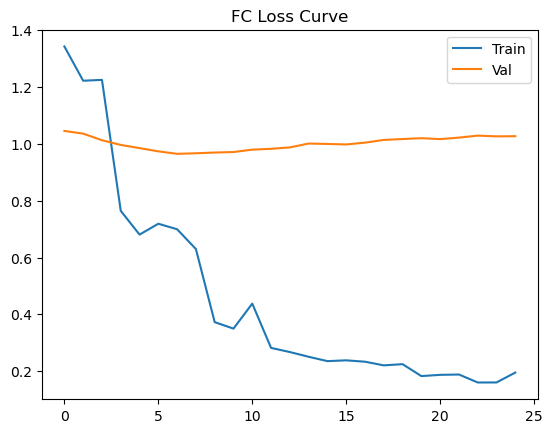

In [52]:
plt.plot(train_losses_fc, label="Train")
plt.plot(val_losses_fc, label="Val")
plt.legend()
plt.title("FC Loss Curve")
plt.savefig("results/loss_plot_fc.png")
plt.show()

## Prediction curve

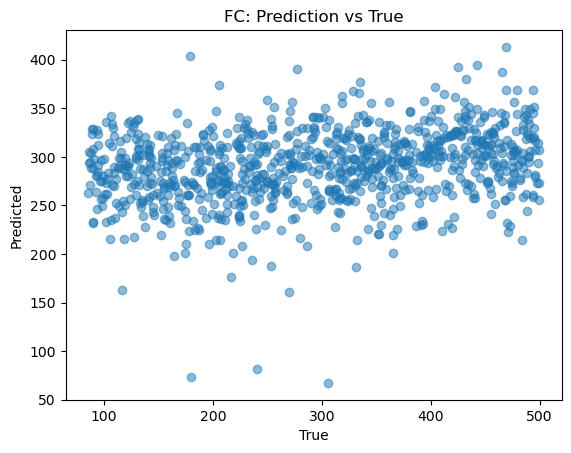

In [53]:
plt.scatter(true_fc, preds_fc, alpha=0.5)
plt.title("FC: Prediction vs True")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.savefig("results/prediction_plot_fc.png")
plt.show()

---
# Comparison

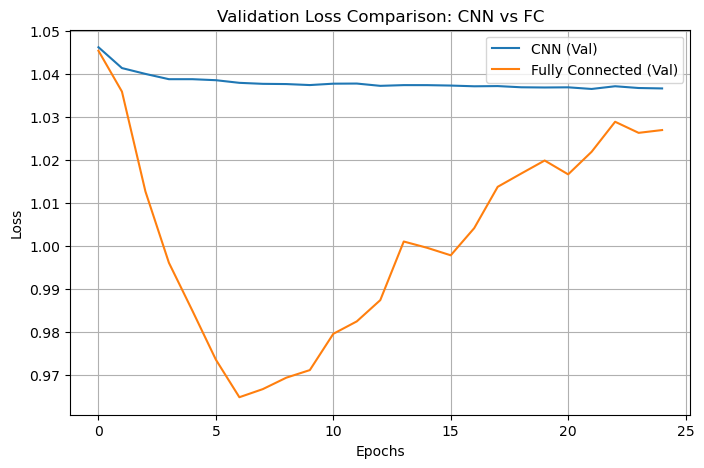

In [55]:
plt.figure(figsize=(8,5))

plt.plot(val_losses_cnn, label="CNN (Val)")
plt.plot(val_losses_fc, label="Fully Connected (Val)")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Validation Loss Comparison: CNN vs FC")
plt.legend()
plt.grid()

plt.savefig("results/validation_loss_comparison.png")
plt.show()

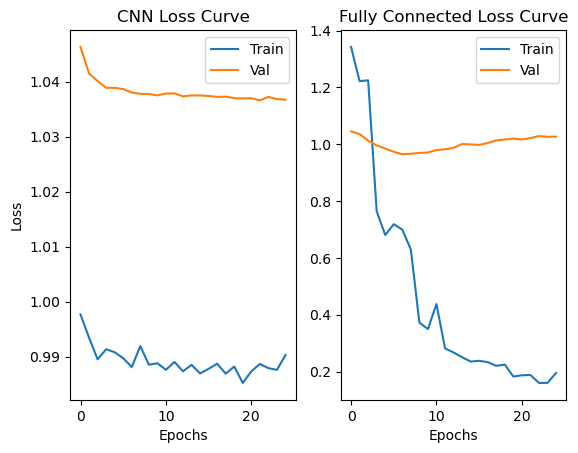

In [56]:
# CNN
plt.subplot(1,2,1)
plt.plot(train_losses_cnn, label="Train")
plt.plot(val_losses_cnn, label="Val")
plt.title("CNN Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# FC
plt.subplot(1,2,2)
plt.plot(train_losses_fc, label="Train")
plt.plot(val_losses_fc, label="Val")
plt.title("Fully Connected Loss Curve")
plt.xlabel("Epochs")
plt.legend()

plt.savefig("results/loss_curve_comparison.png")
plt.show()


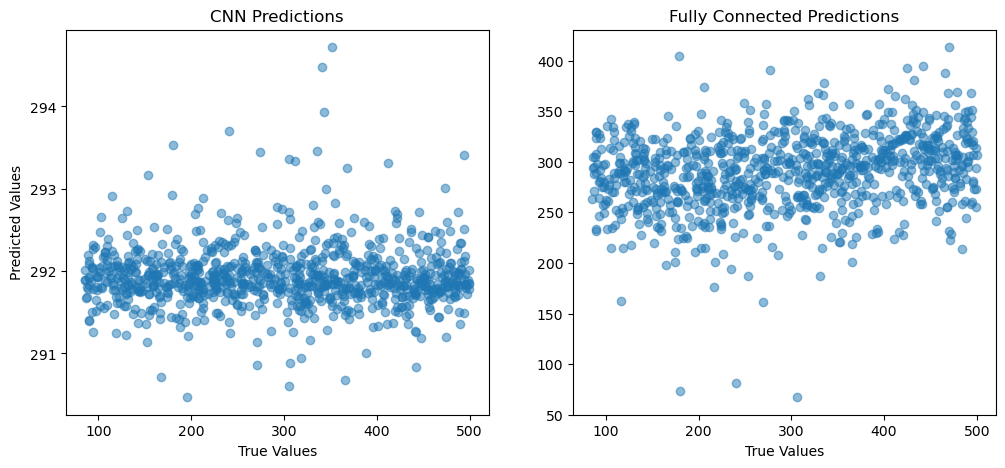

In [57]:
plt.figure(figsize=(12,5))

# CNN
plt.subplot(1,2,1)
plt.scatter(true_cnn, preds_cnn, alpha=0.5)
plt.title("CNN Predictions")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")

# FC
plt.subplot(1,2,2)
plt.scatter(true_fc, preds_fc, alpha=0.5)
plt.title("Fully Connected Predictions")
plt.xlabel("True Values")
plt.savefig("results/prediction_curve_comparison.png")
plt.show()

In [61]:
results = pd.DataFrame({
    "Model": ["CNN", "Fully Connected"],
    "RMSE": [rmse_cnn, rmse_fc],
    "MAE": [mae_cnn, mae_fc],

    "r2_score": [r2_cnn, r2_fc]
})

print(results)

             Model        RMSE         MAE  r2_score
0              CNN  119.822258  103.898515 -0.000783
1  Fully Connected  116.292497   99.026055  0.057311


The Fully Connected model performs better than the CNN, as indicated by lower RMSE and MAE values, along with a positive R² score. While the CNN fails to learn meaningful patterns and exhibits underfitting, the FC model captures some structure in the data despite mild overfitting.

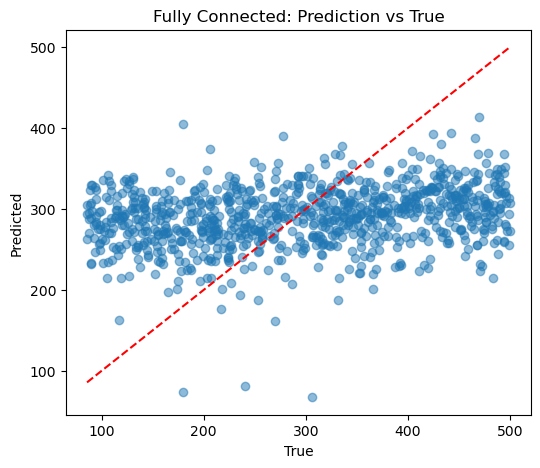

In [62]:
plt.figure(figsize=(6,5))

plt.scatter(true_fc, preds_fc, alpha=0.5)
plt.plot([true_fc.min(), true_fc.max()],
         [true_fc.min(), true_fc.max()],
         'r--')   

plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("Fully Connected: Prediction vs True")
plt.savefig("results/PredvsTrue_comparison.png")
plt.show()

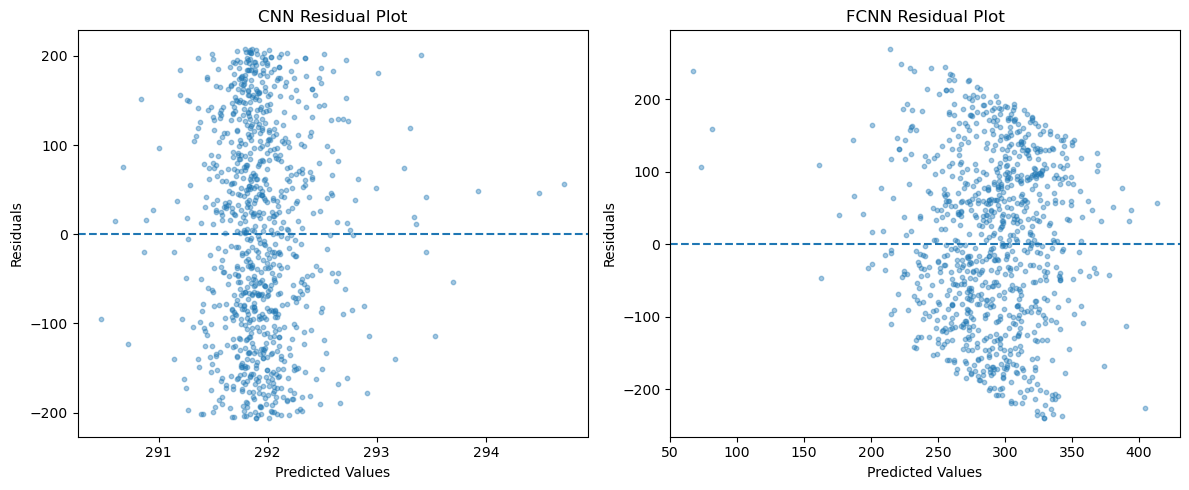

In [68]:
# Convert to numpy
true_cnn = np.array(true_cnn)
preds_cnn = np.array(preds_cnn)

true_fc = np.array(true_fc)
preds_fc = np.array(preds_fc)

# Residuals
residuals_cnn = true_cnn - preds_cnn
residuals_fc = true_fc - preds_fc

# Plot
plt.figure(figsize=(12,5))

# CNN subplot
plt.subplot(1,2,1)
plt.scatter(preds_cnn, residuals_cnn, alpha=0.4, s=10)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("CNN Residual Plot")

# FCNN subplot
plt.subplot(1,2,2)
plt.scatter(preds_fc, residuals_fc, alpha=0.4, s=10)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("FCNN Residual Plot")

plt.tight_layout()
plt.savefig("results/residuals_comparison.png", dpi=300)
plt.show()

## Model Comparison

The performance of the Convolutional Neural Network (CNN) and the Fully Connected (FC) model was compared to understand their learning behavior on the dataset.

The **CNN model** showed minimal improvement in both training and validation loss across epochs. The prediction plot also indicates that the model outputs nearly constant values. This suggests that the CNN was unable to effectively learn meaningful spatial features from the limited dataset, leading to underfitting.

In contrast, the **Fully Connected model** demonstrated a significant decrease in training loss, indicating that it was able to learn patterns from the data. However, the validation loss increased over epochs, showing that the model began to memorize the training data rather than generalize well. This behavior is characteristic of overfitting.

From the *prediction plots*, the FC model produces a wider spread of predictions compared to the CNN, confirming that it captures more variation in the target variable. However, the predictions are still not perfectly aligned with the true values due to overfitting and dataset limitations.

Overall, this comparison *highlights* the trade-off between model complexity and dataset size. While the CNN underfits due to insufficient learning, the Fully Connected model overfits due to high capacity relative to the dataset. **Proper regularization and increased data** can help improve generalization performance.

## Overfitting Control
To prevent overfitting, several techniques were applied. The dataset was split into training and validation sets (80/20), and model performance was monitored using validation loss. Regularization techniques such as dropout and weight decay were used in the fully connected model. Additionally, early stopping was implemented by saving the model with the lowest validation loss.

Despite these measures, some overfitting was observed in the fully connected model due to the high input dimensionality and limited dataset size. This highlights the inherent challenge of generalization in such settings.

## This experiment demonstrates the importance of selecting an appropriate model based on data characteristics and the need for balancing bias and variance.